# Multiclass classification

This example fits a three-class model, prints its tree representation, and renders the same tree with Graphviz.

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from pybrush import BrushClassifier
import graphviz

X, y = make_classification(
    n_samples=180, n_features=6, n_informative=5, n_redundant=0,
    n_classes=3, n_clusters_per_class=1, random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [2]:
model = BrushClassifier(
    pop_size=100, max_gens=100, max_size=40, max_depth=10,
    num_islands=1, random_state=42, verbosity=1,
)
model.fit(X_train, y_train)

print('Test accuracy:', accuracy_score(y_test, model.predict(X_test)))
print('Probability rows sum to:', model.predict_proba(X_test)[:3].sum(axis=1))

Completed 100% [====================]
Test accuracy: 0.7962962962962963
Probability rows sum to: [1. 1. 1.]


In [3]:
print(model.best_estimator_.program.get_model('tree'))

Softmax
|- x_0
|- Mean
|  |- 12.73*x_2
|  |- Min
|  |  |- 55.80*x_5
|  |  |- -7.67
|  |  |- -2.40
|  |  |- 1.00
|  |- -14.89*x_4
|  |- 20.88*x_3
|- Sum
|  |- -1.35*x_3
|  |- -0.76*x_2
|  |- 0.51*x_0


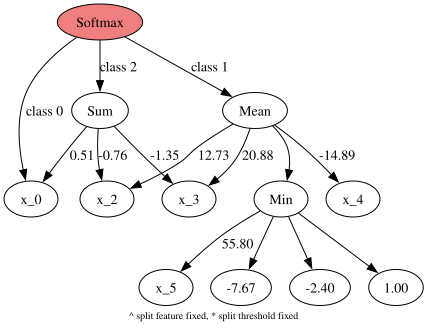

In [4]:
graphviz.Source(model.best_estimator_.program.get_model('dot'))

## Multiclass decision trees only

Set `start_from_decision_trees=True` to restrict the initial model population to split-based class-logit branches. The Softmax root still combines one branch per class.

In [14]:
split_model = BrushClassifier(
    pop_size=100, max_gens=100, max_size=40, max_depth=5, max_stall=10,
    start_from_decision_trees=True,
    functions=['SplitOn', 'SplitBest', 'Add', 'Mul'],
    num_islands=1, random_state=7, verbosity=1,
)
split_model.fit(X_train, y_train)

print('Split-only test accuracy:', accuracy_score(y_test, split_model.predict(X_test)))
print(split_model.best_estimator_.program.get_model('tree'))

Completed  15% [===                 ]Split-only test accuracy: 0.7777777777777778
Softmax
|- 0.30*x_0
|- If(x_4>=-0.47)
|  |- -1.53*x_4
|  |- 3.39
|- If(x_4>=-0.47)
|  |- 0.14*Add
|  |  |- -8.83*x_3
|  |  |- -5.89*x_2
|  |- -0.43*x_2


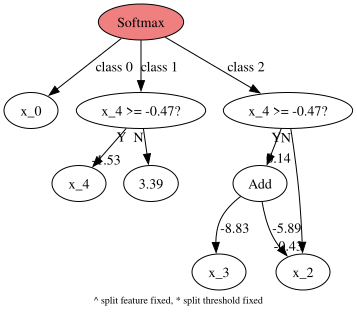

In [15]:
graphviz.Source(split_model.best_estimator_.program.get_model('dot'))